In [9]:
import yfinance as yf

ticker = "AMD"
data = yf.download(tickers=ticker, interval="1m", period="5d")

[*********************100%***********************]  1 of 1 completed


In [17]:
data['SMA_3'] = data['Close'].rolling(window=3).mean()
data['SMA_5'] = data['Close'].rolling(window=5).mean()

In [28]:
data['Signal'] = 0
data['Signal'][5:] = \
    (data['SMA_3'][5:] > data['SMA_5'][5:]).astype(int)

# Position = 1 if we're in the market
data['Position'] = data['Signal'].diff()

/var/folders/3f/31v_62yj0yz9qjk24gp8955h0000gn/T/ipykernel_66492/3676302239.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'][5:] = \


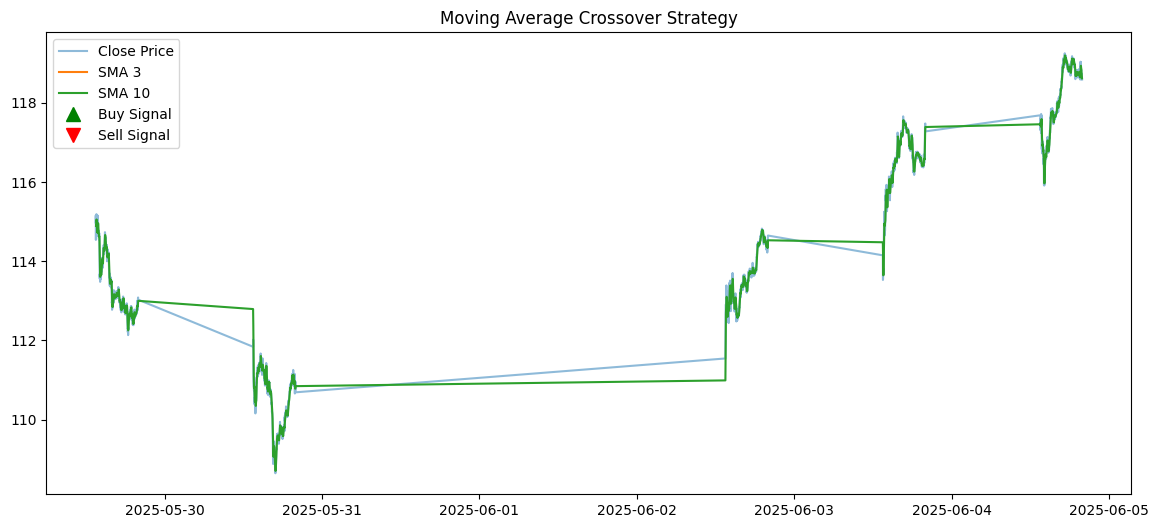

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='Close Price', alpha=0.5)
plt.plot(data['SMA_3'], label='SMA 3')
plt.plot(data['SMA_5'], label='SMA 10')
plt.plot(data[data['Position'] == 1].index,
         data['SMA_3'][data['Position'] == 1],
         '^', markersize=10, color='g', label='Buy Signal')
plt.plot(data[data['Position'] == -1].index,
         data['SMA_3'][data['Position'] == -1],
         'v', markersize=10, color='r', label='Sell Signal')
plt.legend()
plt.title('Moving Average Crossover Strategy')
plt.show()

In [21]:
initial_cash = 1000
cash = initial_cash
position = 0
portfolio_value = []

for i in range(len(data)):
    price = data['Close'].iloc[i]
    signal = data['Position'].iloc[i]

    # BUY SIGNAL
    if signal == 1 and cash > 0:
        position = cash / price  # buy as many shares as possible
        cash = 0  # spend all cash

    # SELL SIGNAL
    elif signal == -1 and position > 0:
        cash = position * price  # sell all shares
        position = 0

    # Track total portfolio value
    total = cash + position * price
    portfolio_value.append(total)

# Add result to DataFrame
data['Portfolio Value'] = portfolio_value


/opt/miniconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/opt/miniconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1355: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


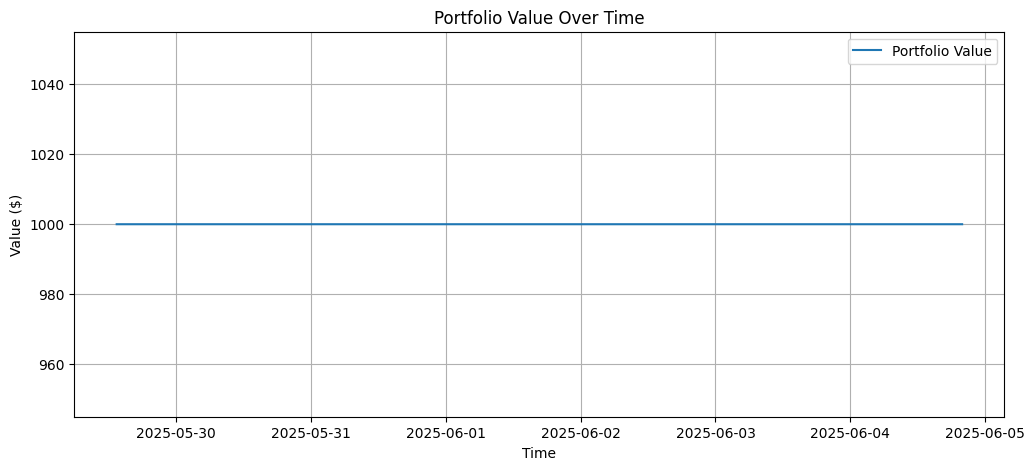

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(data['Portfolio Value'], label='Portfolio Value')
plt.title('Portfolio Value Over Time')
plt.xlabel('Time')
plt.ylabel('Value ($)')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
print(data['Position'].value_counts(dropna=False))

Position
0.0    1933
NaN       1
Name: count, dtype: int64


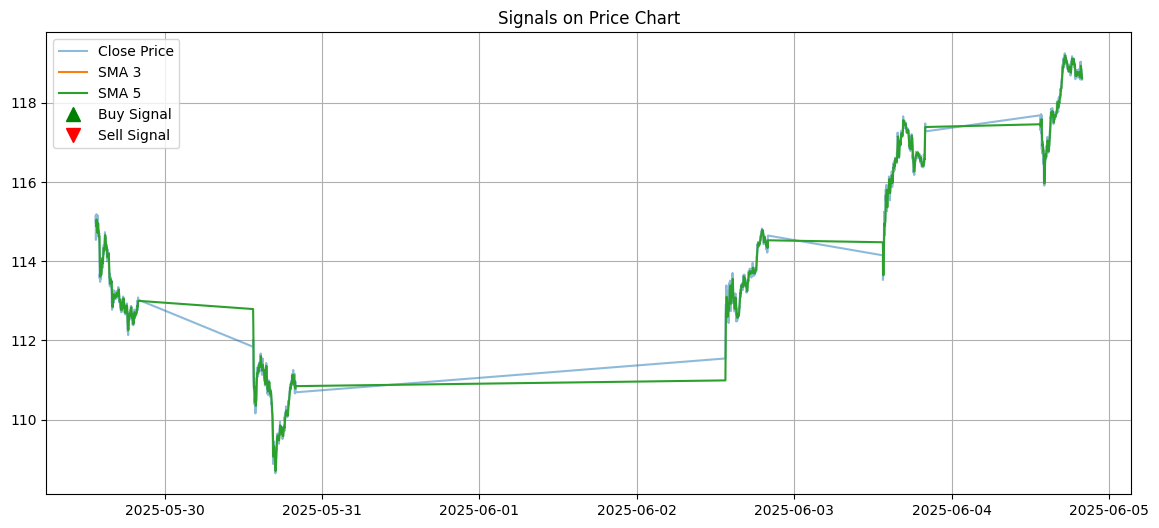

In [25]:
plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='Close Price', alpha=0.5)
plt.plot(data['SMA_3'], label='SMA 3')
plt.plot(data['SMA_5'], label='SMA 5')
plt.plot(data[data['Position'] == 1].index,
         data['Close'][data['Position'] == 1],
         '^', markersize=10, color='g', label='Buy Signal')
plt.plot(data[data['Position'] == -1].index,
         data['Close'][data['Position'] == -1],
         'v', markersize=10, color='r', label='Sell Signal')
plt.legend()
plt.title('Signals on Price Chart')
plt.grid(True)
plt.show()

In [26]:
print(data.head())
print(data.tail())
print(data['Close'].describe())

Price                           Close        High         Low        Open  \
Ticker                            AMD         AMD         AMD         AMD   
Datetime                                                                    
2025-05-29 13:30:00+00:00  114.980003  115.540001  114.870102  115.389999   
2025-05-29 13:31:00+00:00  115.160004  115.379997  114.960503  114.989998   
2025-05-29 13:32:00+00:00  114.540001  115.199997  114.520401  115.139999   
2025-05-29 13:33:00+00:00  114.820000  114.930000  114.423103  114.514999   
2025-05-29 13:34:00+00:00  114.940002  115.124001  114.790001  114.820000   

Price                       Volume SMA_3 SMA_10 Signal Position  \
Ticker                         AMD                                
Datetime                                                          
2025-05-29 13:30:00+00:00  1743342   NaN    NaN      0      NaN   
2025-05-29 13:31:00+00:00   260188   NaN    NaN      0      0.0   
2025-05-29 13:32:00+00:00   205509   NaN    NaN 

In [30]:
cross_up = (data['SMA_3'] > data['SMA_5']) & (data['SMA_3'].shift(1) <= data['SMA_5'].shift(1))
cross_down = (data['SMA_3'] < data['SMA_5']) & (data['SMA_3'].shift(1) >= data['SMA_5'].shift(1))

print("Number of cross ups:", cross_up.sum())
print("Number of cross downs:", cross_down.sum())

Number of cross ups: 0
Number of cross downs: 0
